### Database Identification and Evaluation

**Data Resource Selected:** The AMI Meeting Corpus (Subset: Individual Headset Microphones - IHM)

**a. How will it be used?**
This dataset serves as the foundational proxy for the TRIP Laboratory's simulated communication audio. I have extracted a continuous 3-minute (180-second) sample to strictly comply with the testing parameters while preserving natural conversational flow, including extended speech, dead air, and overlapping dialogue. This unedited array will be passed through a deep learning denoising pipeline to isolate vocal frequencies from the static noise floor, ultimately validating the enhancement via mathematically improved ASR (Speech-to-Text) accuracy.

**b. Why is this data the best option for this project?**
The AMI Corpus perfectly mirrors the acoustic and behavioral profile of the lab's human-factors studies:
1. **Hardware Constraints:** The data is recorded using close-talking headsets, generating the exact hardware artifacts, breathing noise, and static profiles experienced by the lab's research operators.
2. **Behavioral Dynamics:** The dataset captures teams actively coordinating to accomplish structured tasks. It contains the exact conversational nuances—such as micro-affirmations, instructions, and cognitive distractions—that the downstream NLP classification models will be designed to track.

## Installation

In [6]:
# Install the required libraries
!pip install -q librosa matplotlib soundfile

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

KeyboardInterrupt: 

In [1]:
import urllib.request
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from google.colab import files

## Data Ingestion of .wav from AMI Dataset


Data Ingestion: Downloads a continuous 3-minute raw headset recording directly from the AMI Meeting Corpus to mimic TRIP Lab hardware constraints.

In [2]:
print("continuous headset track from the AMI Meeting Corpus")
# AMI Meeting EN2002a, Individual Headset Track 0
url = "https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/EN2002a/audio/EN2002a.Headset-0.wav"
temp_filename = "full_meeting.wav"
urllib.request.urlretrieve(url, temp_filename)

print("Extracting a 3-minute sample")
# We load at 16kHz because our downstream Whisper strictly requires it
audio_array, sample_rate = librosa.load(temp_filename, sr=16000, offset=120.0, duration=180.0)

print(f"Sample Rate: {sample_rate} Hz")
print(f"Total Duration: {len(audio_array) / sample_rate / 60:.2f} minutes")

Extracting a 3-minute sample (skipping 120s of setup)...
Extraction Complete!
Sample Rate: 16000 Hz
Total Duration: 3.00 minutes


# Visualization

Visualizes the time-domain amplitude to identify natural conversational bursts and overlapping team dialogue

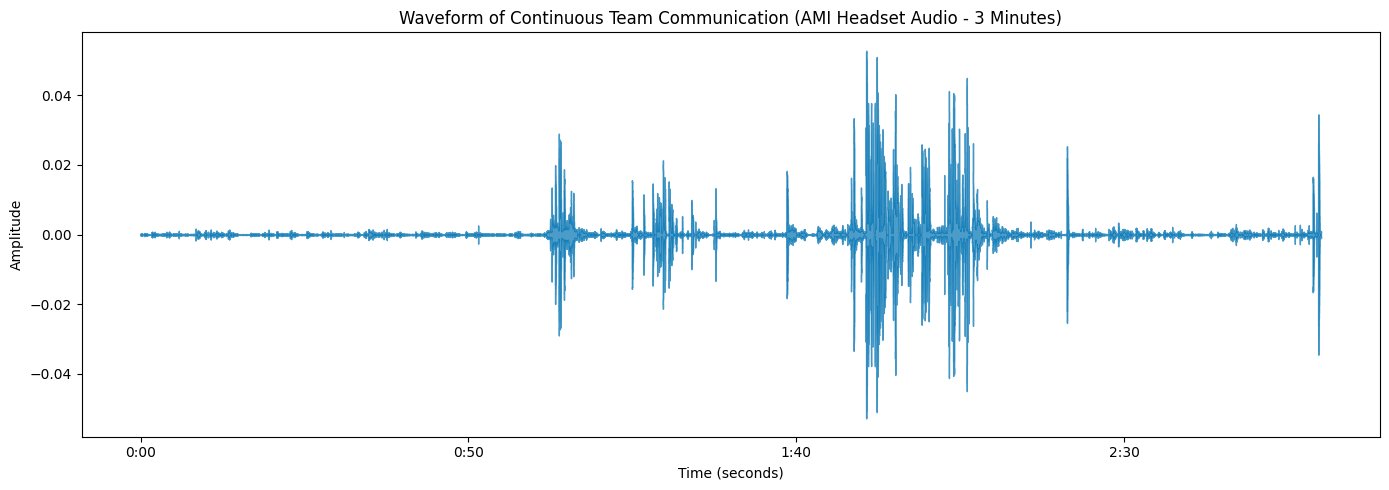

In [3]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y=audio_array, sr=sample_rate, alpha=0.7, color="#0072B2")
plt.title("Waveform of Continuous Team Communication")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

## Mel-Spectrogram (1D to 2D Frequency Heatmap)

Generates a Mel-Spectrogram to visualize the density of the baseline static and room hum that requires denoising.

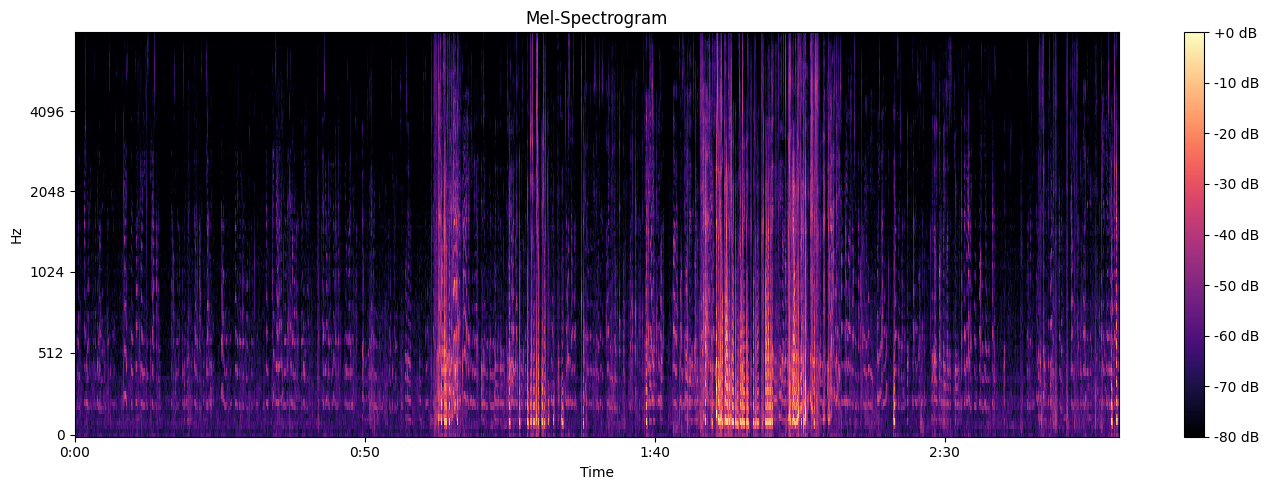

In [4]:
plt.figure(figsize=(14, 5))

# Mel-spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=audio_array, sr=sample_rate, n_mels=128, fmax=8000)
# Convert power to decibels
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# Plot
librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel', fmax=8000, cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-Spectrogram")
plt.tight_layout()
plt.show()

## Download to Export

In [5]:
final_filename = "ami_raw_3min_sample.wav"

# Export the numpy array to a standardized .wav file
sf.write(final_filename, audio_array, sample_rate)
print(f"Saved locally as: {final_filename}")

# browser download
files.download(final_filename)

Saved locally as: ami_raw_3min_sample.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>